<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

## Setup environment

In [ ]:
!python -c "import monai" || pip install -q "monai-weekly"

## Setup imports

In [ ]:
import os
import pprint
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
from sklearn.metrics import classification_report

from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import Dataset, CacheDataset, DataLoader, ThreadDataLoader
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet169
from monai.transforms import (
    Activations,
    AsDiscrete,
    EnsureChannelFirstd,
    EnsureTyped,
    Compose,
    ConcatItemsd,
    LoadImaged,
    RandFlipd,
    RandRotate90d,
    RandZoomd,
    ScaleIntensityRangePercentilesd,
)
from monai.utils import set_determinism

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.6.0
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/<username>/miniforge3/envs/biomonai_ignite/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.3
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.0
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: NOT INSTALLED or UNKNOWN VERSION.
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.0
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERS

## Download Rxrx1 subset data

The original Rxrx1 dataset is very large (45 GB) and designed for prediction of more than 1000 classes. To avoid lengthy download times, we will utilize a subset of Rxrx1, which was sampled in a random and balanced manner. For practical purposes, the classification target is changed from `sirna_id` (>1000 classes) to `cell_type` (4 classes). For each of the 4 cell types (HEPG2/HUVEC/RPE/U2OS), 250 samples were randomly selected for training (1000 samples total) and 50 for testing (200 samples total). 

We are first going to download the dataset and then load the `metadata.csv` table to create training and test dataframes.

**Note:** The original Rxrx1 sample indices are stored in the column `original_row_index` in file `./rxrx1_subset_monai/metadata.csv`.

In [ ]:
url = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/rxrx1_subset_monai.zip"
download_and_extract(
    url, filepath="./rxrx1_subset_monai.zip", output_dir=".", hash_val="5eea02f6b0a6d8cbce6ad66949257438"
)

rxrx1_subset_monai.zip: 468MB [02:25, 3.38MB/s]                              

2026-04-08 22:34:42,209 - INFO - Downloaded: rxrx1_subset_monai.zip


2026-04-08 22:34:42,666 - INFO - Verified 'rxrx1_subset_monai.zip', md5: 5eea02f6b0a6d8cbce6ad66949257438.
2026-04-08 22:34:42,666 - INFO - Writing into directory: ..


## Prepare dataframes and datalists

We use `pandas` to read the `metadata.csv` file and split the data into train/test sets.

In [ ]:
df_all = pd.read_csv("./rxrx1_subset_monai/metadata.csv")
dftrain = df_all.loc[df_all.dataset == "train", :].reset_index()
dftest = df_all.loc[df_all.dataset == "test", :].reset_index()

class_map = {c: idx for idx, c in enumerate(dftrain.cell_type.unique())}
class_map_inv = dict(enumerate(dftrain.cell_type.unique()))
num_classes = len(class_map)
class_names = list(class_map.keys())

print(dftrain.columns)
dftrain

Index(['index', 'original_row_index', 'site_id', 'well_id', 'cell_type',
       'dataset', 'experiment', 'plate', 'well', 'site', 'well_type', 'sirna',
       'sirna_id'],
      dtype='str')


,index,original_row_index,site_id,well_id,cell_type,dataset,experiment,plate,well,site,well_type,sirna,sirna_id
0,0,45589,HEPG2-01_3_C15_2,HEPG2-01_3_C15,HEPG2,train,HEPG2-01,3,C15,2,positive_control,s15652,1114
1,1,59951,HEPG2-07_2_H02_2,HEPG2-07_2_H02,HEPG2,train,HEPG2-07,2,H02,2,treatment,s195435,683
2,2,48708,HEPG2-02_4_D13_1,HEPG2-02_4_D13,HEPG2,train,HEPG2-02,4,D13,1,treatment,s20197,85
3,3,46896,HEPG2-02_1_E09_1,HEPG2-02_1_E09,HEPG2,train,HEPG2-02,1,E09,1,treatment,s27069,313
4,4,60402,HEPG2-07_3_D09_1,HEPG2-07_3_D09,HEPG2,train,HEPG2-07,3,D09,1,treatment,s18250,405
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,123921,U2OS-03_2_G21_2,U2OS-03_2_G21,U2OS,train,U2OS-03,2,G21,2,treatment,s37346,1046
996,996,121453,U2OS-02_2_G19_2,U2OS-02_2_G19,U2OS,train,U2OS-02,2,G19,2,treatment,s38759,164
997,997,119034,U2OS-01_2_H20_1,U2OS-01_2_H20,U2OS,train,U2OS-01,2,H20,1,treatment,s21714,785
998,998,118168,U2OS-01_1_C05_1,U2OS-01_1_C05,U2OS,train,U2OS-01,1,C05,1,treatment,s19455,999


### Create datalists for training and validation
These are lists of dictionaries, with image dict-keys pointing to filepaths, plus a label dict-key.

To construct the filepaths, we follow the same folder- and filenaming pattern from the full Rxrx1 dataset.

(Note: For details, please find instructions in [./rxrx1_subset_monai/README.md#metadata](./rxrx1_subset_monai/README.md#metadata))

In [ ]:
base_path_rxrx1 = os.path.join(".", "rxrx1_subset_monai")
datalists = []
for df in [dftrain, dftest]:
    datalist = []
    for row in range(df.shape[0]):
        d = {}
        s = df.loc[row, :]
        filepaths = []
        for c in [1, 2, 3, 4, 5, 6]:
            subpath = os.path.join("images", s.experiment, f"Plate{s.plate}")
            fn = f"{s.well}_s{s.site}_w{c}.png"
            d[f"c{c}"] = os.path.join(base_path_rxrx1, subpath, fn)
        d["label"] = class_map[s.cell_type]
        datalist.append(d)
    datalists.append(datalist)
datalist_train, datalist_test = tuple(datalists)

# print 3 example train samples
pp = pprint.PrettyPrinter()
pp.pprint(datalist_train[:3])

[{'c1': './rxrx1_subset_monai/images/HEPG2-01/Plate3/C15_s2_w1.png',
  'c2': './rxrx1_subset_monai/images/HEPG2-01/Plate3/C15_s2_w2.png',
  'c3': './rxrx1_subset_monai/images/HEPG2-01/Plate3/C15_s2_w3.png',
  'c4': './rxrx1_subset_monai/images/HEPG2-01/Plate3/C15_s2_w4.png',
  'c5': './rxrx1_subset_monai/images/HEPG2-01/Plate3/C15_s2_w5.png',
  'c6': './rxrx1_subset_monai/images/HEPG2-01/Plate3/C15_s2_w6.png',
  'label': 0},
 {'c1': './rxrx1_subset_monai/images/HEPG2-07/Plate2/H02_s2_w1.png',
  'c2': './rxrx1_subset_monai/images/HEPG2-07/Plate2/H02_s2_w2.png',
  'c3': './rxrx1_subset_monai/images/HEPG2-07/Plate2/H02_s2_w3.png',
  'c4': './rxrx1_subset_monai/images/HEPG2-07/Plate2/H02_s2_w4.png',
  'c5': './rxrx1_subset_monai/images/HEPG2-07/Plate2/H02_s2_w5.png',
  'c6': './rxrx1_subset_monai/images/HEPG2-07/Plate2/H02_s2_w6.png',
  'label': 0},
 {'c1': './rxrx1_subset_monai/images/HEPG2-02/Plate4/D13_s1_w1.png',
  'c2': './rxrx1_subset_monai/images/HEPG2-02/Plate4/D13_s1_w2.png',
  'c

## Writing a custom image converter for visualization

For visualization of the 6-channel images, we need to convert them to RGB (3-channel) images first. <br>
We write a custom function, which assumes 6-channel image inputs (as channel-first). <br>
For conversion of channels to colors, we follow the color-mapping described and visualized on the Rxrx1 website (i.e. Figure 6 in https://www.rxrx.ai/rxrx1#the-data):

- Nuclei -> blue
- Endoplasmic reticuli -> green
- Actin -> red
- Nucleoli -> cyan
- Mitochondria -> magenta
- Golgi apparatus -> yellow

In [ ]:
def img_6to3_channel(img6ch):
    img = torch.zeros((img6ch.shape[1], img6ch.shape[2], 3))
    # nuclei (blue)
    img[:, :, 2] += img6ch[0, :, :]
    # endoplasmic reticuli (green)
    img[:, :, 1] += img6ch[1, :, :]
    # actin (red)
    img[:, :, 0] += img6ch[2, :, :]
    # nucleoli (cyan)
    img[:, :, 1] += img6ch[3, :, :]
    img[:, :, 2] += img6ch[3, :, :]
    # mitochondria (magenta)
    img[:, :, 0] += img6ch[4, :, :]
    img[:, :, 2] += img6ch[4, :, :]
    # golgi apparatus (yellow)
    img[:, :, 0] += img6ch[5, :, :]
    img[:, :, 1] += img6ch[5, :, :]
    # normalize RGB channels
    img = img / 3.0
    return img

## Robust multi-channel normalization during pre-processing

Each multi-spectral channel has a different range of intensities, and there might be variation across the multi-well plates, across batches, or across experiments. If not properly accounted for, the input to the neural networks has a lot of variation in the individual channels which might affect classification performance.

In the following two code cells, we are going to load a few sample images, and visualize them in two ways:
1. Without any pre-processing (note: when passing multi-spectral images to the visualization function, we still need to divide intensities by 255.0, to bring pixels from the range [0, 255] to the expected color range [0.0, 1.0]).
2. With a more suitable pre-processing: robust normalization of the [1,99]-percentile intensity ranges, individually per channel, to the output range [0.0, 1.0] (with clipping). This process is also called [winsorization](https://en.wikipedia.org/wiki/Winsorizing) and is a useful technique for robust intensity normalization in medical imaging. We use the intensity transform [`ScaleIntensityRangePercentilesd`](https://docs.monai.io/en/stable/transforms.html#scaleintensityrangepercentilesd) from MONAI Core for winsorization.

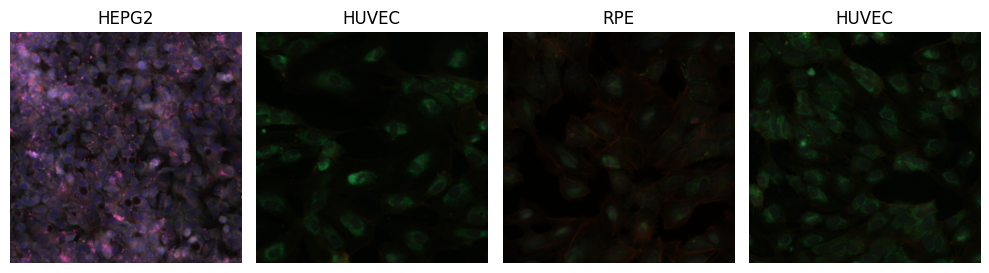

In [ ]:
# visualize test batch without normalization
set_determinism(seed=0)
transforms_visualize = Compose(
    [
        LoadImaged(keys=["c1", "c2", "c3", "c4", "c5", "c6"], image_only=True),
        EnsureChannelFirstd(keys=["c1", "c2", "c3", "c4", "c5", "c6"]),
        ConcatItemsd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], name="image", dim=0),
    ]
)

batch_size_viz = 4
viz_ds = Dataset(datalist_train, transform=transforms_visualize)
viz_loader = DataLoader(viz_ds, batch_size=batch_size_viz, shuffle=True, num_workers=0)
batch_data = next(iter(viz_loader))

fig, axs = plt.subplots(1, batch_size_viz, figsize=(10, 10 * batch_size_viz), dpi=100)
for idx, img6ch in enumerate(batch_data["image"]):
    axs[idx].imshow(img_6to3_channel(img6ch) / 255.0)
    axs[idx].set_axis_off()
    axs[idx].set_title(class_map_inv[int(batch_data["label"][idx])])
fig.set_tight_layout(True)
# fig.savefig('./batch_without_normalization.png',bbox_inches='tight')
plt.show()

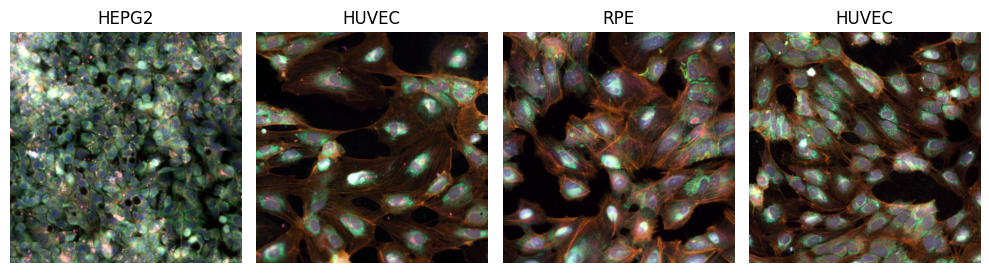

In [ ]:
# visualize test batch with normalization
set_determinism(seed=0)
transforms_visualize = Compose(
    [
        LoadImaged(keys=["c1", "c2", "c3", "c4", "c5", "c6"], image_only=True),
        EnsureChannelFirstd(keys=["c1", "c2", "c3", "c4", "c5", "c6"]),
        ScaleIntensityRangePercentilesd(
            keys=["c1", "c2", "c3", "c4", "c5", "c6"], lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], name="image", dim=0),
    ]
)

batch_size_viz = 4
viz_ds = Dataset(datalist_train, transform=transforms_visualize)
viz_loader = DataLoader(viz_ds, batch_size=batch_size_viz, shuffle=True, num_workers=0)
batch_data = next(iter(viz_loader))

fig, axs = plt.subplots(1, batch_size_viz, figsize=(10, 10 * batch_size_viz), dpi=100)
for idx, img6ch in enumerate(batch_data["image"]):
    axs[idx].imshow(img_6to3_channel(img6ch))
    axs[idx].set_axis_off()
    axs[idx].set_title(class_map_inv[int(batch_data["label"][idx])])
fig.set_tight_layout(True)
# fig.savefig('./batch_with_normalization.png',bbox_inches='tight')
plt.show()

## Set deterministic training for reproducibility

In [ ]:
set_determinism(seed=0)

## Create transforms, CacheDataset and DataLoader

In [ ]:
transforms_train = Compose(
    [
        LoadImaged(keys=["c1", "c2", "c3", "c4", "c5", "c6"], image_only=True),
        EnsureChannelFirstd(keys=["c1", "c2", "c3", "c4", "c5", "c6"]),
        ScaleIntensityRangePercentilesd(
            keys=["c1", "c2", "c3", "c4", "c5", "c6"], lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], name="image", dim=0),
        EnsureTyped(keys=["image", "label"], track_meta=False),
        RandRotate90d(keys=["c1", "c2", "c3", "c4", "c5", "c6"], prob=0.75),
        RandFlipd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], spatial_axis=[0, 1], prob=0.5),
        RandZoomd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ]
)

transforms_val = Compose(
    [
        LoadImaged(keys=["c1", "c2", "c3", "c4", "c5", "c6"], image_only=True),
        EnsureChannelFirstd(keys=["c1", "c2", "c3", "c4", "c5", "c6"]),
        ScaleIntensityRangePercentilesd(
            keys=["c1", "c2", "c3", "c4", "c5", "c6"], lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], name="image", dim=0),
    ]
)

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_classes)])

batch_size_train = 8
train_ds = CacheDataset(datalist_train, transform=transforms_train, num_workers=10)
train_loader = ThreadDataLoader(train_ds, batch_size=batch_size_train, shuffle=True)

Loading dataset: 100%|██████████| 1000/1000 [00:15<00:00, 62.98it/s]


## Define the model, loss and optimizer

For the model, we use the [DenseNet169](https://docs.monai.io/en/stable/networks.html#densenet169) architecture from MONAI Core. It allows to specify the number of input channels at constructor level with the `in_channels` parameter (e.g. grayscale: 1, RGB: 3, multiplexed fluoroscopy: 6).

It also allows to load weights that were pre-trained on ImageNet, effectively turning this into a transfer learning task.

In [ ]:
import torch 
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
device = "cuda:0"
model = DenseNet169(spatial_dims=2, in_channels=6, out_channels=num_classes, pretrained=True)
# Note: In the DenseNet169 constructor, the parameter in_channels=6 already adds a
#       6-channel input layer to the network and connects it to the following
#       ImageNet-pretrained layers. Alternatively, we could also manually replace
#       the first convolutional layer as such:
# first_conv = nn.Conv2d(6, 64, 7, 2, 3, bias=False)
# model.features.conv0 = first_conv
model.to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-5)
max_epochs = 4
val_interval = 1
auc_metric = ROCAUCMetric()

## Execute a typical PyTorch training loop

Note: Typically, one would use a validation set to observe overfitting. For simplicity, we are skipping this here, but you can refer to other tutorials for an example, e.g. the [mednist_tutorial.ipynb](../2d_classification/mednist_tutorial.ipynb).

In [ ]:
import time

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
epoch_times = []  # NEW

for epoch in range(max_epochs):
    epoch_start_time = time.time()  # NEW

    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        print(f"{step}/{len(train_ds) // train_loader.batch_size}, "
              f"train_loss: {loss.item():.4f}")

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)

    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # TIME CALCULATION
    epoch_time = time.time() - epoch_start_time
    epoch_times.append(epoch_time)

    print(f"epoch {epoch + 1} time: {epoch_time:.2f} seconds")  # NEW

# FINAL STATS
mean_time = np.mean(epoch_times)
std_time = np.std(epoch_times)

print(f"\nAverage epoch time: {mean_time:.2f} ± {std_time:.2f} seconds")

----------
epoch 1/4
1/125, train_loss: 1.3759
2/125, train_loss: 1.4210
3/125, train_loss: 1.3214
4/125, train_loss: 1.3437
5/125, train_loss: 1.3232
6/125, train_loss: 1.2942
7/125, train_loss: 1.2881
8/125, train_loss: 1.2704
9/125, train_loss: 1.4242
10/125, train_loss: 1.2138
11/125, train_loss: 1.3022
12/125, train_loss: 1.3157
13/125, train_loss: 1.2112
14/125, train_loss: 1.3071
15/125, train_loss: 1.2370
16/125, train_loss: 1.3398
17/125, train_loss: 1.2712
18/125, train_loss: 1.1453
19/125, train_loss: 1.1153
20/125, train_loss: 1.1447
21/125, train_loss: 1.2353
22/125, train_loss: 1.0170
23/125, train_loss: 1.2121
24/125, train_loss: 1.0051
25/125, train_loss: 1.0880
26/125, train_loss: 1.2019
27/125, train_loss: 1.1938
28/125, train_loss: 1.0031
29/125, train_loss: 1.0977
30/125, train_loss: 1.1448
31/125, train_loss: 0.9836
32/125, train_loss: 1.2166
33/125, train_loss: 1.1895
34/125, train_loss: 1.0132
35/125, train_loss: 1.0874
36/125, train_loss: 1.0672
37/125, train_lo

In [ ]:
torch.cuda.max_memory_allocated() / 1024**2

6560.1552734375

## Evaluation on test set and classification report

We can now evaluate the trained model on the hold-out test set. 

In [ ]:
batch_size_test = 32
test_ds = Dataset(datalist_test, transform=transforms_val)
test_loader = DataLoader(test_ds, batch_size=batch_size_test, shuffle=False, num_workers=4)

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = (
            test_data["image"].to(device),
            test_data["label"].to(device),
        )
        pred = model(test_images).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

       HEPG2     0.9804    1.0000    0.9901        50
       HUVEC     1.0000    0.9800    0.9899        50
         RPE     0.8929    1.0000    0.9434        50
        U2OS     1.0000    0.8800    0.9362        50

    accuracy                         0.9650       200
   macro avg     0.9683    0.9650    0.9649       200
weighted avg     0.9683    0.9650    0.9649       200



Cell-type classification works at a high accuracy (f1-score: 0.97) on this simple example. To a degree, this is due to the fact that we performed transfer learning with our DenseNet CNN, using weights that were pre-trained on ImageNet. 

Feel free to re-run training, but without transfer learning (i.e. `model = DenseNet169(..., pretrained=False)`), and observe how the classification accuracy changes.